# $\Psi(2S)$ discovery with CMS data
#### Gabriele Radano, Matteo Bellino - Spring semester 2025

# 0. Importing packages

In [44]:
# Importing packages
import pickle as pkl                 # Needed to import the pkl files
import numpy  as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from dataclasses import dataclass
from scipy.integrate import quad     # Numerical integral evaluation, useful to compute the integral of the model inside the bin
import sys                           # Needed to know what's the highest float value accepted

# 1. Loading data

In [46]:
# Importing data from files
with open('DataSet.pkl', 'rb') as file: # The 'rb' stands for 'read binary', necessary for this kind of file
    data_HS = pkl.load(file)            # Data with High Statistics 
    
with open('DataSet_lowstat.pkl', 'rb') as file:
    data_LS = pkl.load(file)            # Data with Low Statistics

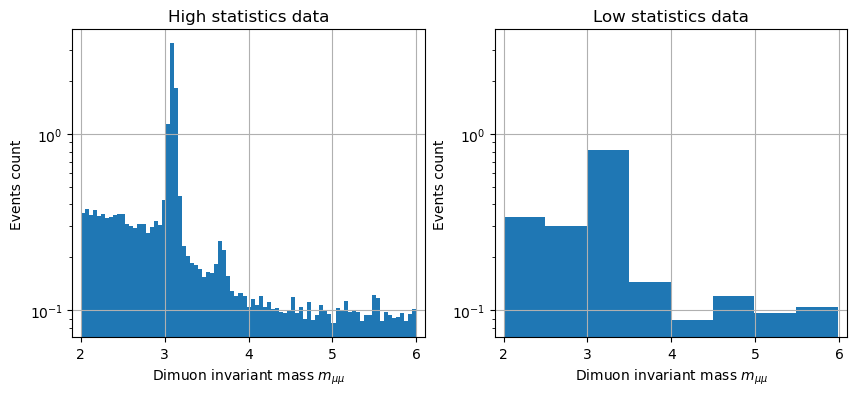

In [47]:
# Plotting raw data
normalize = True
scale     = 'log'
bin_num   = int(np.sqrt(len(data_HS))/2)

fig, axes = plt.subplots(1,2, figsize=(10,4))

ax = axes[0]
ax.grid(1)
ax.hist(data_HS, density=normalize, bins=bin_num)
ax.set_title('High statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_yscale(scale)
ylim = ax.set_ylim()

ax = axes[1]
ax.grid(1)
ax.hist(data_LS, density=normalize, bins=int(bin_num/10))
ax.set_title('Low statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_ylim(ylim)
ax.set_yscale(scale)
plt.show()

# 2. Defining the model

## 2.1. Bare background

Following the instructions of the README file, we will model the bare background (and with that I mean without the
peak of the J/$\Psi$ resonance) with Chebychev polynomial of order three. 
Being honest, they are not super clear about what this is so I had to dig inside the CERN definitions of tools they use to fit.
[There](https://root.cern/doc/master/ChebyshevPol_8h_source.html), at line 66, we see how the third order Chebyshev polynomial is evaluated.
Apparently, it returns
\begin{equation}
    c_3 \cdot (4x^3-3x) + c_2\cdot(2x^2 - 1) + c_1\cdot x + c_0
\end{equation}
but this has four parameters! However we shall factor in also the normalization condition: its integral between 2 and 6 must equal one. With this constraint, the most general polynomial of order 3 is
\begin{equation}
    ax^3+bx^2+cx+\left(\frac{1}{4}-4c-\frac{52}{3}b-80a\right)
\end{equation}


In [51]:
#definition of Cheb. polynomials of order n (they are orthonormal in [-1,1]) 
def T(x, n):
    return np.cos(n * np.arccos(x))

def chebn(x, max_order, params):
    total = 0
    if len(params) != (max_order+1):
        print("Dim of params must match the order of the polynomial")
        return None
    
    for order in range(0,max_order+1):
        total += params[order] * T(x, order)
    return total

#I read that often people using cheb set the consant term to 1
def cheb3(x, params):
    a1, a2, a3 = params
    return a3*(4*x**3-3*x) + a2*(2*x**2-1) + a1*x + 1

def cheb3r(z, params): 
    '''Rescaled cheb polynomial of order 3
    
    This function maps the value of the cheb polynomials from -1 to 1 (where they form an orthogonal set) 
    to the interval of interest [2,6], then performs the normalization.
    The order 0 coefficient is assumed to be 1'''
    
    a1, a2, a3 = params #they are not relative to the normalized distribution!!
    x = -1 + 2*(z-2) / (6-2) #I'm making a change of var so then I'll have to divide the function by dx/dz = 2
    norm = 2 - 2/3 * a2 #normalization IN THE INTERVAL [-1,1] (space of coord x)
    return (a3*(4*x**3-3*x) + a2*(2*x**2-1) + a1*x + 1) / norm / 2 #factor 2 accounts for change of coord

#numpy.chebychev and numpy.chebyshev.b

#Other option for chebychev polynomials
def cheb3rr(z, params): 
    '''Rescaled cheb polynomial of order 3
    
    Here each polynomial has been normalized and translated by 1 before taking the linear combination'''
    
    a0, a1, a2, a3 = params #they are not relative to the normalized distribution!!
    x = -1 + 2*(z-2) / (6-2) #I'm making a change of var so then I'll have to divide the function by dx/dz = 2
    norm =  a0 + a1 + a2 + a3 #normalization IN THE INTERVAL [-1,1] (space of coord x)
    
    return (a3*(4*x**3-3*x +1)/2 + a2*3/2*x**2 + a1*(x+1)/2 + a0/2) / norm / 2 #factor 2 accounts for change of coord
    

1.0


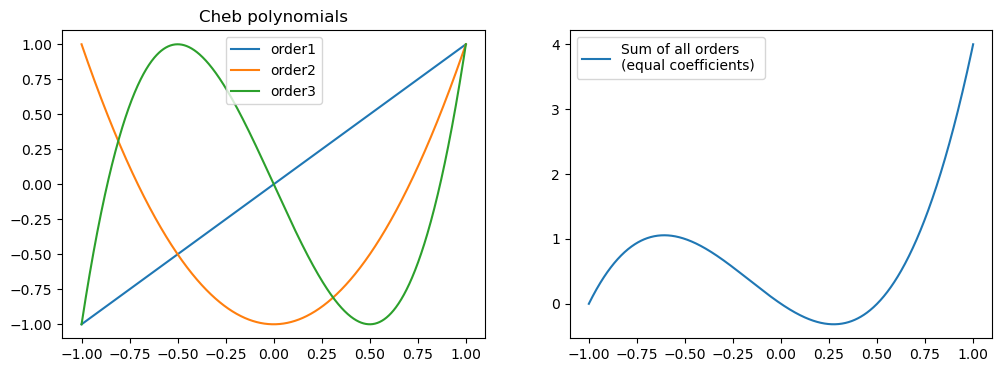

In [52]:
#check noramlization
integral, _ =quad(lambda x : cheb3rr(x, [1,1,1,1]), 2, 6)
print(integral)

#here I hust plot the polinomials and sum them in interval [-1,1]
params = [1,1,1,1]
max_order = 3
x = np.linspace(-1,1, 1000)
y_npoly = [T(x, n) for n in range(1,max_order+1)]
#print(y_poly)

plt.figure(figsize = (12,4))
plt.subplot(121)
plt.title("Cheb polynomials")
count = 0
for y_poly in y_npoly:
    count += 1
    plt.plot(x,y_poly, label = "order" + str(count))
    
plt.legend()
plt.subplot(122)
plt.plot(x, chebn(x, 3, params), label = "Sum of all orders \n(equal coefficients) ")
plt.legend()




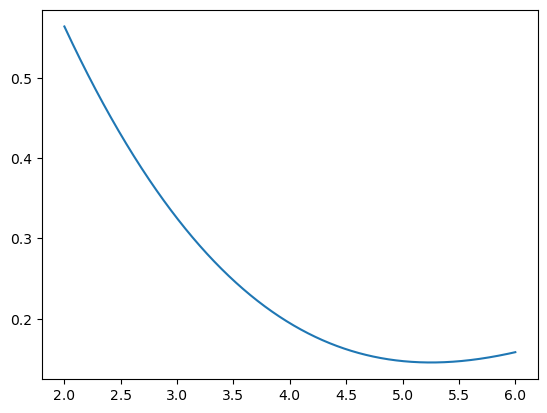

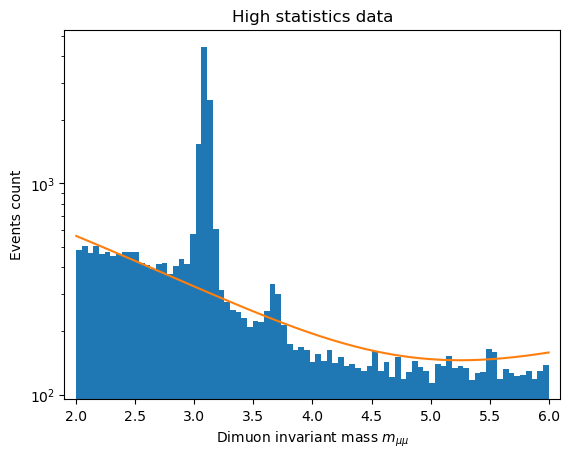

In [53]:
x = np.linspace(2,6, 1000)
y = cheb3r(x, [-0.7, 0.3, -0.03])
plt.plot(x,y)
plt.figure()
#plt.yscale('log')
plt.hist(data_HS, density=False, bins=bin_num)
plt.title('High statistics data')
plt.xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
plt.ylabel('Events count')
plt.xlim((1.9,6.1))
plt.yscale(scale)
ylim = plt.ylim()
plt.plot(x,y*1000)

In [54]:
def poly3(x, params):
    '''A generic polynomial of order 3 normalized between 2 and 6.

    It needs three parameters, (a,b,c), the coefficients of the polynomial 
                ax^3+bx^2+cx+fixed_by_normalization
    where the term of order 0 is fixed by the normalization condition.'''
    a,b,c = params
    value = a*x**3 + b*x**2 + c*x + (1/4-4*c-52*b/3-80*a) 
    return value

In [55]:
def get_binned_model(model, params, bin_edges):
    '''Numerical integral of the model

    This function returns the integral of the given model, integrated inside each bin, so that it can be
    compared with the binned data. IMPORTANT: It requires the parameters of the model which MUST be normalized be-
    tween 2 and 6; the n+1 edges of the n bins used to bin the data. It returns an array with n entries
    (one per bin) containing the integral of the model evaluated in that bin.'''
    
    integrand = lambda x: model(x, params)
    Nbins = len(bin_edges)-1
    binned_model = [0] * Nbins 
    
    for i in range(0, Nbins):
        lower_extreme = bin_edges[i]
        upper_extreme = bin_edges[i+1]
        binned_model[i], _ = quad(integrand, lower_extreme, upper_extreme)
    
    binned_model = np.array(binned_model)
    #print(np.sum(binned_model))
    return binned_model
    

In [56]:
@dataclass
class get_bNLL(): # Function to evaluate the binned Negative Log Likelihood
    data:       np.array
    bin_number: int
    model:      callable # Not the model but a function that evaluates its integral inside each bin. It
                         # the model parameters and the edges of the bin (n+1 edges for n bins)

    def __post_init__(self):
        self.binned_data, self.bin_edges = np.histogram(self.data, bins=self.bin_number, density=False)

    def __call__(self, params):
        '''Evaluates the binned Negative Log Likelihood

        This function only requires the parameters of the model being used
        It is the callable function of the class get_bNLL which already has the binned data, the bin edges 
        and the model we are comparing the data to.
        We assume that the number of points inside each bin follows a Poisson distribution: the parameter
        lambda (the expectation value of events inside each bin) is the model's integral over the same bin.'''

        N_model = len(self.data) # THIS IS JUST FOR TESTING <---------------------------------------------------------------------------
        binned_model = get_binned_model(self.model, params, self.bin_edges) * N_model #multiplied by the number of data since the output of get-binned_model is normalized

        x = np.linspace(2,6, 10000) # To ensure we don't consider models with negative values <-----------------------------------------
        if any(self.model(x,params)<0):
            bNLL = sys.float_info.max # This is the highest possible float supported by the computer
        else:
            bNLL = sum( binned_model - self.binned_data*np.log(binned_model) )

        return bNLL    

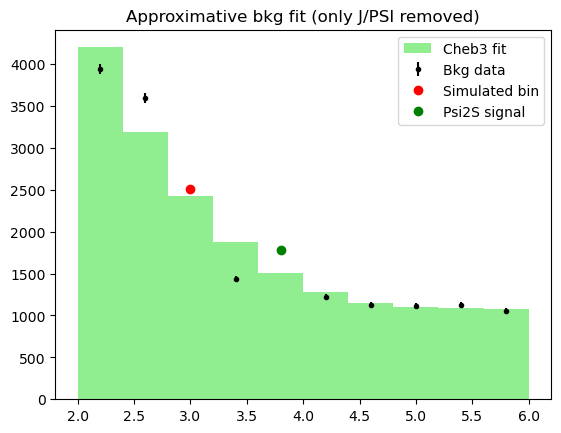

In [57]:
#polynomial fit
Nbins = 10
fake_dataset = np.array([3]*2512) #We made up this dataset in order to simulate (approximately) the background in the removed part
                                  #We chose to make the bin 2512 high because it is the mean between the two surrounding bin counts (2512)

data_simil_bkg = np.concatenate((data_HS[(data_HS<2.8) | (data_HS>3.3)], fake_dataset ))

bNLL_HS_poly3 = get_bNLL(data=data_simil_bkg,
                         bin_number=Nbins,
                         model=poly3)
initial_params = [0,0,0]
optimization_results = minimize(bNLL_HS_poly3, initial_params)

optimized_params = optimization_results.x
x = np.linspace(2,6)

data_counts, bin_edges = np.histogram(data_simil_bkg, bins=Nbins, density = False)
err_data_counts = np.sqrt(data_counts)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
bin_widths = np.diff(bin_edges)

binned_result = get_binned_model(poly3, optimized_params, bin_edges) * len(data_simil_bkg)

plt.bar(bin_edges[:-1], binned_result, width=np.diff(bin_edges), align='edge', color = 'lightgreen', label="Cheb3 fit")#, edgecolor = "black")
plt.errorbar(bin_centers, data_counts, yerr = err_data_counts, fmt = ".", linestyle = "None", color='black', label='Bkg data')
plt.errorbar(bin_centers[2], data_counts[2], fmt = "o", color = "red", label = "Simulated bin")
plt.errorbar(bin_centers[4], data_counts[4], fmt = "o", color = "green", label = "Psi2S signal")
plt.title("Approximative bkg fit (only J/PSI removed)")
plt.legend()
plt.show()

[ 1.15579279 -0.60083206  0.18582413 -0.06582395]


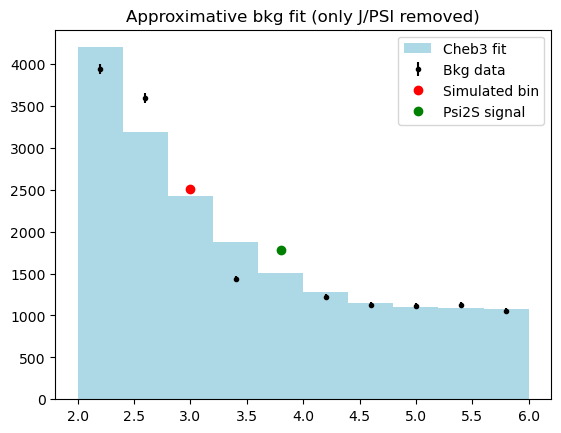

In [58]:
#cheb3 fit
Nbins = 10

fake_dataset = np.array([3]*2512) #We made up this dataset in order to simulate (approximately) the background in the removed part
                                  #We chose to make the bin 2512 high because it is the mean between the two surrounding bin counts (2512)

data_simil_bkg = np.concatenate((data_HS[(data_HS<2.8) | (data_HS>3.3)], fake_dataset ))

bNLL_HS_cheb3r = get_bNLL(data=data_simil_bkg,
                         bin_number=Nbins,
                         model=cheb3rr)
initial_params = [1., -0.7, 0.3, -0.03] #given by the project instructions

optimization_results = minimize(bNLL_HS_cheb3r, initial_params,  method='L-BFGS-B')
optimized_params = optimization_results.x
print(optimized_params)
x = np.linspace(2,6,1000)

data_counts, bin_edges = np.histogram(data_simil_bkg, bins=Nbins, density = False)
err_data_counts = np.sqrt(data_counts)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
bin_widths = np.diff(bin_edges)

binned_result = get_binned_model(cheb3rr, optimized_params, bin_edges) * len(data_simil_bkg)

plt.bar(bin_edges[:-1], binned_result, width=np.diff(bin_edges), align='edge', color = 'lightblue', label="Cheb3 fit")#, edgecolor = "black")
plt.errorbar(bin_centers, data_counts, yerr = err_data_counts, fmt = ".", linestyle = "None", color='black', label='Bkg data')
plt.errorbar(bin_centers[2], data_counts[2], fmt = "o", color = "red", label = "Simulated bin")
plt.errorbar(bin_centers[4], data_counts[4], fmt = "o", color = "green", label = "Psi2S signal")
plt.title("Approximative bkg fit (only J/PSI removed)")
plt.legend()
plt.show()